# Outlier Detection and handling

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import statistics

In [3]:
data = pd.read_csv('House_Price.csv')

In [4]:
data.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [5]:
type(data)

pandas.core.frame.DataFrame

In [6]:
# Function to Detect Outlier on one-dimension dataset.
def find_outliers(data):
    outliers = []

    random_data_std = statistics.stdev(data)
    random_data_mean = statistics.mean(data)

    anomaly_cut_off = random_data_std * 3

    lower_limit  = random_data_mean - anomaly_cut_off
    upper_limit = random_data_mean + anomaly_cut_off

    for outlier in data:
        if outlier > upper_limit or outlier < lower_limit:
            outliers.append(outlier)
    return outliers

In [7]:
outlier_detection = find_outliers(data['Price'])

In [8]:
len(outlier_detection)

42

In [9]:
data.Price.skew()

np.float64(6.523349573058705)

<Axes: xlabel='Price', ylabel='Density'>

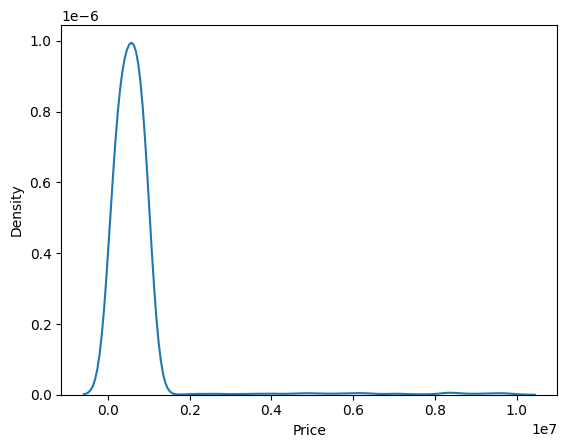

In [10]:
sns.kdeplot(data.Price)

In [11]:
data['transformed_price'] = np.log(data.Price)

In [12]:
data.transformed_price.skew()

np.float64(-0.11783094716825372)

In [13]:
finding_outliers = find_outliers(data.transformed_price)

In [14]:
len(finding_outliers)

31

<Axes: xlabel='transformed_price', ylabel='Density'>

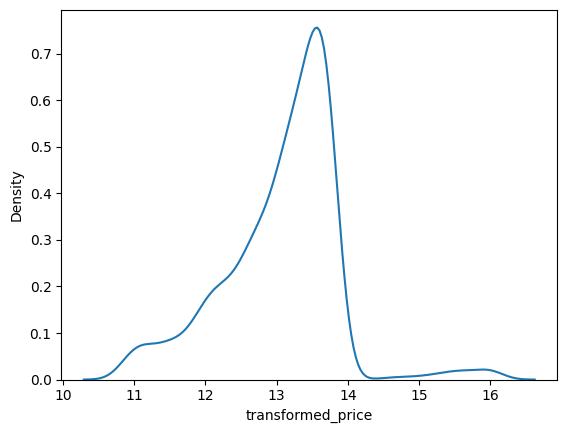

In [15]:
sns.kdeplot(data.transformed_price)

In [16]:
dataset= [11,10,12,14,12,15,14,13,15,102,12,14,17,19,107, 10,13,12,14,12,108,12,11,14,13,15,10,15,12,10,14,13,15,10]

In [17]:
# Using Z Score
outliers=[]
def detect_outliers(data):
    threshold = 3
    mean = np.mean(data)
    std = np.std(data)
    for i in data:
        z_score = (i - mean)/std
        if np.abs(z_score) > threshold:
            outliers.append(i)
    return outliers

In [18]:
detect_outliers(dataset)

[102, 107, 108]

In [19]:
dataset = sorted(dataset)

In [20]:
q1,q3 = np.percentile(dataset, [25, 75])
print(q1,q3)

12.0 15.0


In [21]:
iqr = q3 - q1
print(iqr)

3.0


In [22]:
# Find upper & lower fence
lower_fence = q1 - (1.5 * iqr)
upper_fence = q3 + (1.5 * iqr)
print(lower_fence, upper_fence)

7.5 19.5


<Axes: >

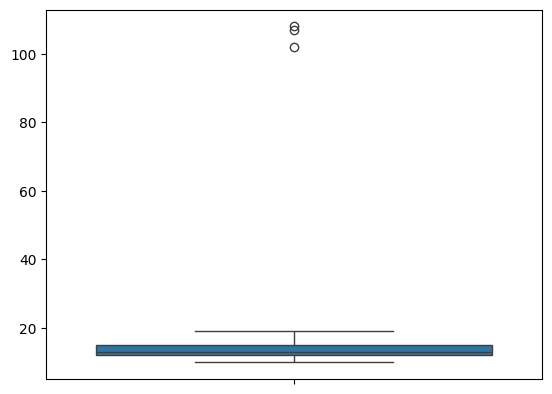

In [23]:
sns.boxplot(dataset)

In [23]:
# Outlier Removing Code

In [24]:
arr = np.array([2, 3, 4, 6, 7, 9, 11, 45, 64, 78, 112, 999])
arr

array([  2,   3,   4,   6,   7,   9,  11,  45,  64,  78, 112, 999])

In [30]:
Q1 = np.percentile(arr, 25)
Q3 = np.percentile(arr, 75)
IQR = Q3 - Q1
upper_fence = Q3 + (1.5 * IQR)
lower_fence = Q1 - (1.5 * IQR)
lists = []
for i in arr:
    if i >= lower_fence and i <= upper_fence:
      lists.append(i)

np.array(lists)

array([  2,   3,   4,   6,   7,   9,  11,  45,  64,  78, 112])